✅ Data successfully loaded from 'gr_log_data.csv'



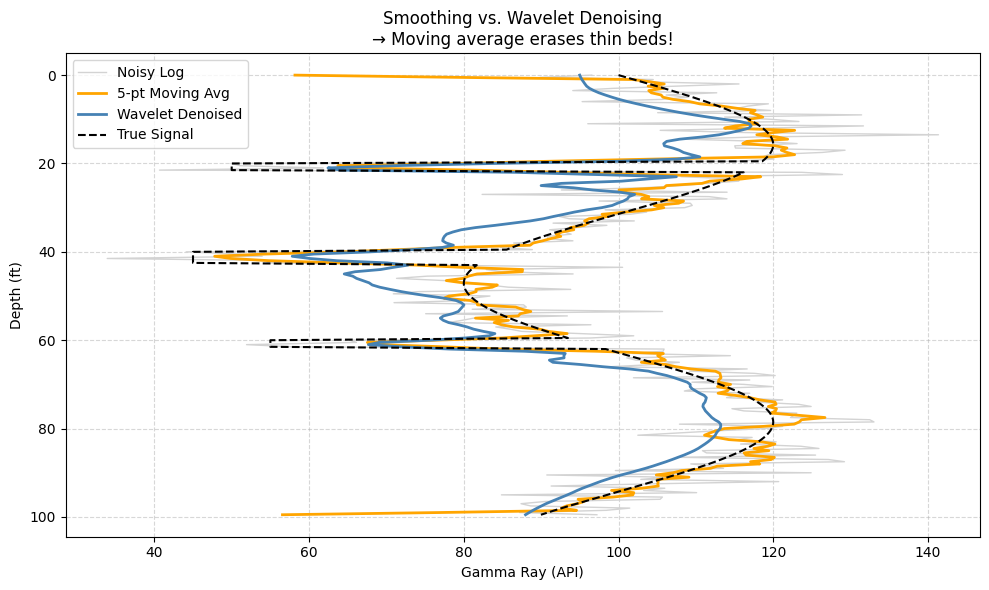

In [3]:

import numpy as np
import matplotlib.pyplot as plt
import pywt

# ==========================================
# 2. Read Data from CSV
# ==========================================
# Read the data back from the CSV file
data_read = np.loadtxt('gr_log_data.csv', delimiter=',', skiprows=1)
depth_read = data_read[:, 0]
gr_true_read = data_read[:, 1]
gr_noisy_read = data_read[:, 2]
print("✅ Data successfully loaded from 'gr_log_data.csv'\n")

# ==========================================
# 3. Denoising Methods
# ==========================================
# ❌ Method 1: Moving average (destroys thin beds)
gr_smooth = np.convolve(gr_noisy_read, np.ones(5)/5, mode='same')

# ✅ Method 2: Wavelet denoising (preserves edges)
coeffs = pywt.wavedec(gr_noisy_read, 'db4', level=4)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745  # noise estimate
uthresh = sigma * np.sqrt(2 * np.log(len(gr_noisy_read)))
coeffs_thresh = [pywt.threshold(c, uthresh, mode='soft') for c in coeffs]
gr_denoised = pywt.waverec(coeffs_thresh, 'db4')

# Trim to original length (wavelet may add padding)
gr_denoised = gr_denoised[:len(gr_noisy_read)]

# ==========================================
# 4. Plotting
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(gr_noisy_read, depth_read, 'lightgray', linewidth=1, label='Noisy Log')
plt.plot(gr_smooth, depth_read, 'orange', linewidth=2, label='5-pt Moving Avg')
plt.plot(gr_denoised, depth_read, 'steelblue', linewidth=2, label='Wavelet Denoised')
plt.plot(gr_true_read, depth_read, 'black', linestyle='--', linewidth=1.5, label='True Signal')

plt.gca().invert_yaxis()
plt.xlabel('Gamma Ray (API)')
plt.ylabel('Depth (ft)')
plt.title('Smoothing vs. Wavelet Denoising\n→ Moving average erases thin beds!')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig('log_denoising_comparison.png', dpi=300, bbox_inches='tight')
plt.show()